# Thailand (single-zone)

A single-zone (Thailand) capacity-expansion run with **13 cascading Mekong-basin reservoirs** -- Bhumibol, Sirikit, Srinagarind, Vajiralongkorn, Rajjaprabha, etc. Migrated from the v1.4-era xlsx dataset to the v1.9 long-format CSV schema; all per-station reservoir physics (head, tailrace-discharge curves, forebay-volume curves) preserved.

**Run the solve from the command line** (the dataset is large -- 1M+ variables -- so a full solve takes ~30 min):

```bash
cd examples/thailand
python run.py
```

The cells below explore the dataset shape and read the result NetCDF. They run fast (no solve).


In [1]:
import pathlib

# Walk up to find the example dir (containing config.json + input/).
this_dir = pathlib.Path.cwd()
while not (this_dir / 'config.json').exists() or not (this_dir / 'input').is_dir():
    if this_dir == this_dir.parent:
        raise RuntimeError(
            'Could not locate the example dir; run from inside '
            'examples/thailand/.'
        )
    this_dir = this_dir.parent
INPUT = this_dir / 'input'
print(f'Example dir: {this_dir}')
print(f'Input:       {INPUT}')

Example dir: /Users/energy/01-doing/PREP-SHOT-tutorial/PREP-SHOT/examples/thailand
Input:       /Users/energy/01-doing/PREP-SHOT-tutorial/PREP-SHOT/examples/thailand/input


## Existing fleet (2023)

Thailand's installed capacity in the start year, with `Large Hydropower` allocated across the 13 reservoir techs by their rated capacity.

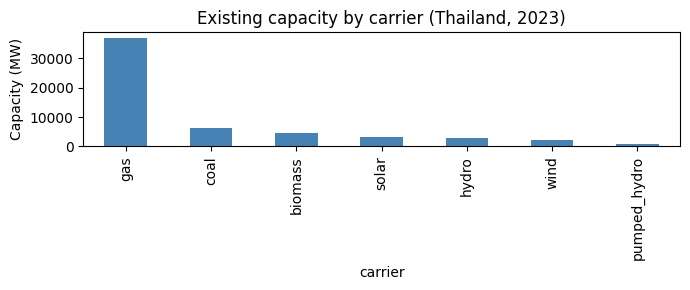

carrier
gas             36993.0
coal             6138.0
biomass          4705.0
solar            3186.0
hydro            2925.0
wind             2092.0
pumped_hydro     1000.0
Name: capacity, dtype: float64

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

fleet = pd.read_csv(INPUT / 'tech_existing.csv')
registry = pd.read_csv(INPUT / 'tech_registry.csv')
merged = fleet.merge(registry[['tech', 'carrier']], on='tech')
by_carrier = merged.groupby('carrier')['capacity'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
by_carrier.plot.bar(ax=ax, color='steelblue')
ax.set_ylabel('Capacity (MW)')
ax.set_title('Existing capacity by carrier (Thailand, 2023)')
fig.tight_layout()
plt.show()
by_carrier.round(0)

## Per-station hydropower characteristics

Each reservoir is modeled with its own head, capacity, and operational bounds -- the feature that distinguishes PREP-SHOT from PyPSA / GenX.

In [3]:
head = pd.read_csv(INPUT / 'reservoir_head.csv')
cap  = pd.read_csv(INPUT / 'reservoir_capacity_max.csv')
merged = (
    head[['tech', 'head']]
    .merge(cap[['tech', 'capacity_max']], on='tech')
    .sort_values('capacity_max', ascending=False)
)
merged.round(1)

,tech,head,capacity_max
0,Bhumibol,154.0,779.2
10,Srinagarind,140.0,720.0
1,Sirikit,113.6,500.0
12,Vajiralongkorn,92.0,300.0
9,Rajjaprabha,94.0,240.0
4,Pak_Mun,17.0,136.0
7,Bang_Lang,85.0,84.0
2,Chulabhorn,70.0,40.0
11,Tha_Thung_Na,30.0,39.0
5,Siridhorn,42.0,36.0


## Inspect a solve (after running `python run.py`)

Once you've run the CLI command above and it has written `output/baseline.nc`, the cell below opens it. Skip if you haven't run the solve yet.

In [4]:
import xarray as xr

nc_path = this_dir / 'output' / 'baseline.nc'
if not nc_path.exists():
    print(f'No NetCDF at {nc_path}. Run `python run.py` from {this_dir} first.')
else:
    # Try netCDF4 then h5netcdf -- the .nc file is netCDF4-classic and
    # may not be readable by every backend on every platform.
    ds = None
    for engine in ('netcdf4', 'h5netcdf'):
        try:
            ds = xr.open_dataset(nc_path, engine=engine)
            break
        except Exception as exc:
            last_err = exc
    if ds is None:
        print(f'Could not open {nc_path} (last error: {last_err}). '
              f'Falling back to baseline.xlsx in the cells below.')
    else:
        print(f'Total cost (NPV): ${float(ds.cost):,.0f}')
        print(f'Variables: {sorted(ds.data_vars)[:6]} ...')


Total cost (NPV): $7,317,497,191
Variables: ['carbon', 'carbon_breakdown', 'charge', 'cost', 'cost_fix', 'cost_fix_breakdown'] ...


## Common plots from a solved baseline

Once `python run.py` writes `output/baseline.nc` (and `baseline.xlsx`),
the cells below produce four standard diagnostics:

1. **Installed capacity** by technology
2. **Annual generation mix** by technology
3. **Daily dispatch profile** (stacked area over the year)
4. **Cost breakdown** (NPV decomposition)

The cells read from the `.xlsx` mirror so you don't need a working
`netCDF4` build to view results.

In [5]:
OUT = this_dir / 'output' / 'baseline.xlsx'
if not OUT.exists():
    raise FileNotFoundError(
        f'No solved baseline at {OUT}. Run `python run.py` from {this_dir} first.'
    )
xl = pd.ExcelFile(OUT)
print('Sheets:', xl.sheet_names[:8], '...')

Sheets: ['trans_export', 'gen', 'install', 'carbon', 'charge', 'cost_var_breakdown', 'cost_fix_breakdown', 'cost_newtech_breakdown'] ...


### Installed capacity

Single-year, single-zone, so capacity reduces to one horizontal bar
per technology.

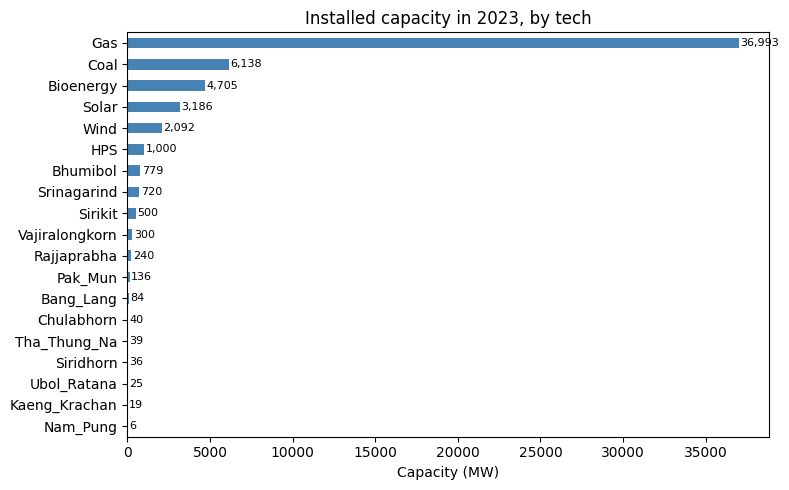

In [6]:
inst = pd.read_excel(xl, 'install')
by_tech = (inst.groupby('tech')['install']
           .sum().sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 5))
by_tech.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Capacity (MW)')
ax.set_ylabel('')
ax.set_title('Installed capacity in 2023, by tech')
for i, v in enumerate(by_tech.values):
    ax.text(v + 100, i, f'{v:,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### Annual generation mix

Annual TWh per technology. Note how much of the load is met by gas
and coal — the dataset has no carbon cap, so the dispatch is
driven purely by variable cost.

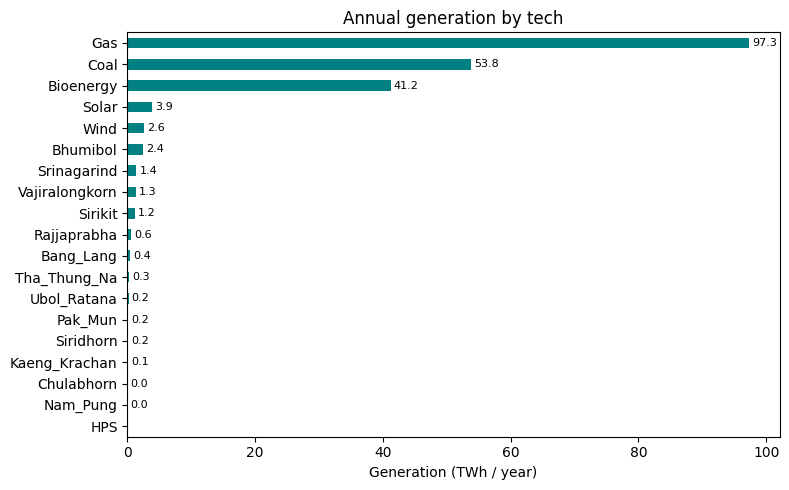

In [7]:
gen = pd.read_excel(xl, 'gen')
by_tech_twh = (gen.groupby('tech')['gen']
               .sum().div(1e6).sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 5))
by_tech_twh.plot.barh(ax=ax, color='teal')
ax.set_xlabel('Generation (TWh / year)')
ax.set_ylabel('')
ax.set_title('Annual generation by tech')
for i, v in enumerate(by_tech_twh.values):
    if v > 0.01:
        ax.text(v + 0.5, i, f'{v:,.1f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### Daily dispatch profile

Aggregate hourly generation into daily means and stack by
technology to see seasonal dynamics. Hydro output rises with the
monsoon; gas plays the swing role; renewables are roughly flat.

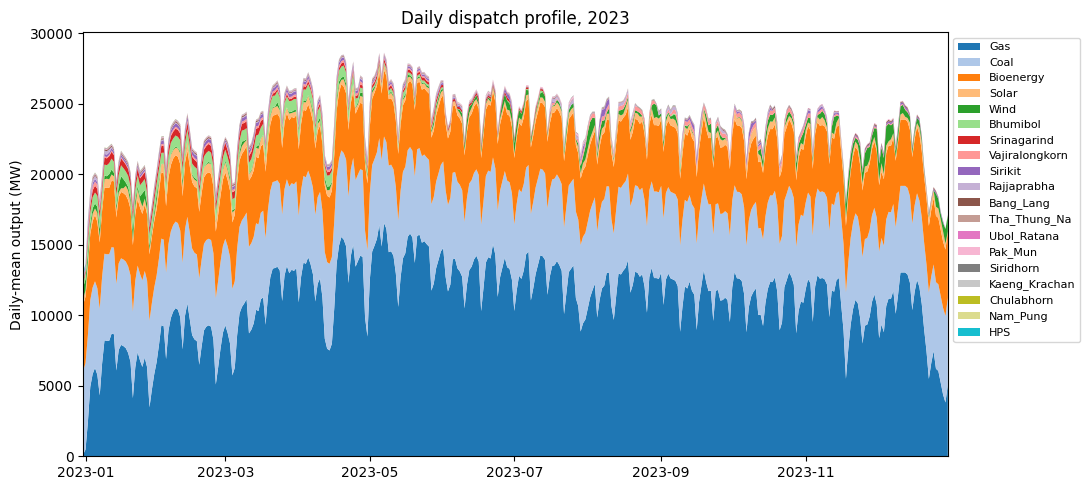

In [8]:
# gen[hour=1..8760, tech] -> reshape to (day, tech) and stack.
gen_pivot = gen.pivot_table(index='hour', columns='tech',
                            values='gen', aggfunc='sum').fillna(0)
gen_pivot.index = pd.to_datetime('2022-12-31') + pd.to_timedelta(gen_pivot.index, unit='h')
daily = gen_pivot.resample('D').mean()  # MW (daily-mean output)

tech_order = (gen_pivot.sum(axis=0).sort_values(ascending=False).index.tolist())
daily = daily[tech_order]

fig, ax = plt.subplots(figsize=(11, 5))
ax.stackplot(daily.index, daily.T.values, labels=tech_order,
             colors=plt.cm.tab20.colors)
ax.set_ylabel('Daily-mean output (MW)')
ax.set_title('Daily dispatch profile, 2023')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=8, ncol=1)
ax.margins(x=0)
plt.tight_layout()
plt.show()

### Cost breakdown

All costs are NPV-discounted to the start year. With no expansion
(carbon cap is `inf` in this scenario), `cost_newtech` and
`cost_newline` are 0 — the model only pays operating costs on the
existing fleet.

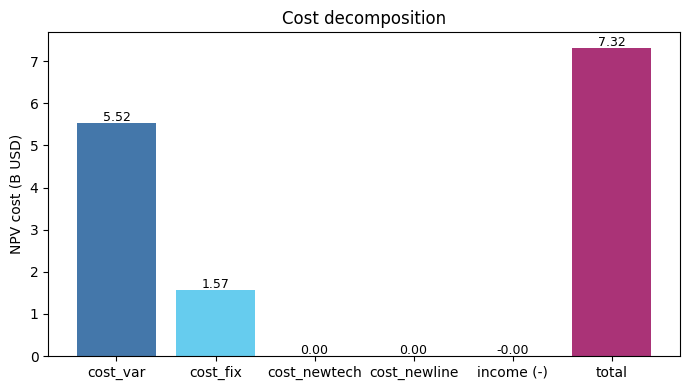

In [9]:
components = ['cost_var', 'cost_fix', 'cost_newtech', 'cost_newline']
values = [pd.read_excel(xl, c).iloc[0, 1] / 1e9 for c in components]
income = pd.read_excel(xl, 'income').iloc[0, 1] / 1e9
total = pd.read_excel(xl, 'cost').iloc[0, 1] / 1e9

labels = components + ['income (-)', 'total']
vals = values + [-income, total]
colors = ['#4477aa', '#66ccee', '#228833', '#ccbb44',
          '#ee6677', '#aa3377']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, vals, color=colors)
for i, v in enumerate(vals):
    ax.text(i, v + 0.05, f'{v:,.2f}', ha='center', fontsize=9)
ax.set_ylabel('NPV cost (B USD)')
ax.set_title('Cost decomposition')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Where to next

- [Quickstart notebook](../../doc/source/Quickstart.ipynb) -- the canonical 5-minute walkthrough on a smaller 3-zone synthetic dataset.
- [Southeast Asia notebook](../southeast_asia/SoutheastAsia.ipynb) -- a 5-country regional case with 57 reservoirs.
- [Model Inputs/Outputs](../../doc/source/Model_input_output.rst) -- every file in `input/` documented.